# Indexing 2: point-by-point indexing (1 degree mosaicity)

Point-by-point (pbp) indexing with ImageD11: for every voxel of a grid in the
sample plane, the peaks whose diffraction path passes through that voxel are
indexed separately, and up to `gmax` candidate grains are kept per voxel.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
from pathlib import Path

# make the repository importable, whatever the working directory is
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "simtools").is_dir())
sys.path.insert(0, str(REPO))

import os
import time

import numpy as np
import matplotlib.pyplot as plt
import ImageD11.cImageD11
import ImageD11.grain
import ImageD11.unitcell
import ImageD11.sinograms.point_by_point as pbp
from ImageD11.nbGui import nb_utils as utils
from simtools import dummy, io, paths, plot

plot.dark()

In [2]:
SAMPLE = "domains_mosaicity_1p0deg"
colf = io.read_peaks(paths.peaks_path(SAMPLE))
print(f"{colf.nrows} peaks")

ypositions, ystep, ymin, y0 = dummy.add_pbp_columns(colf)
ny = len(ypositions)
nomega = len(np.unique(colf.omega))
print(f"{ny} translations with peaks, step {ystep:.5f} um, rotation axis at y0 = {y0}")

Reading your columnfile in hdf format
895177 peaks
99 translations with peaks, step 0.10198 um, rotation axis at y0 = 0.0


In [3]:
pars = colf.parameters.parameters
ucell = ImageD11.unitcell.unitcell(
    [pars["cell__a"], pars["cell__b"], pars["cell__c"], pars["cell_alpha"], pars["cell_beta"], pars["cell_gamma"]],
    pars["cell_lattice_[P,A,B,C,I,F,R]"],
)
ucell.makerings(colf.ds.max())

In [4]:
savefile = os.path.join(paths.process_dir(SAMPLE), "peaks_2d")
dset = dummy.dset(colf.copy(), paths.PARFILE, savefile, ny, nomega)
assert dset.ymin == ymin
assert dset.ymax == ypositions[-1]
assert np.allclose(dset.ystep, ystep)
assert np.allclose(dset.ostep, 0.5)
dset.save()

## Parameters

In [5]:
percent_peaks_to_use = 60  # strongest peaks used to generate trial orientations
eta_wedge = 6  # peaks within this many degrees of eta = 0 / 180 are not used
etacut = np.abs(np.sin(np.radians(eta_wedge)))
ifrac = np.percentile(colf.sum_intensity, 100 - percent_peaks_to_use) / colf.sum_intensity.max()
print(f"Using {percent_peaks_to_use}% of the peaks with intensity > {ifrac:.5f} * Imax")

pbpmanager = pbp.PBP(
    dset.parfile,
    dset,
    hkl_tol=0.04,  # peaks within this distance of integer hkl are assigned to a grain
    fpks=0.25,  # fraction of the predicted peaks a trial grain needs
    ds_tol=0.01,  # tolerance (1/A) on the ring assignment
    etacut=etacut,
    ifrac=ifrac,
    gmax=10,  # candidate grains kept per voxel
    cosine_tol=np.cos(np.radians(90 - dset.ostep)),
    y0=y0,
    symmetry="cubic",
    foridx=[0, 1, 2, 3, 4, 5, 6],  # rings used for indexing
    forgen=[1, 4],  # rings used to generate trial orientations
    uniqcut=0.25,
)
pbpmanager.setpeaks(colf.copy())

Using 60% of the peaks with intensity > 0.00011 * Imax
0 0.4277 (1, 1, 1) 8 9143 used, sum_intensity> 64.0
1 0.4939 (2, 0, 0) 6 6520 used, sum_intensity> 23.82679331977276
2 0.6985 (0, 2, 2) 12 13738 used, sum_intensity> 19.75325025837497
3 0.8191 (1, 3, 1) 24 27434 used, sum_intensity> 24.628841887684235
4 0.8555 (2, 2, 2) 8 9753 used, sum_intensity> 15.206377418356801
5 0.9878 (4, 0, 0) 6 7019 used, sum_intensity> 4.059324209570077
6 1.0765 (1, 3, 3) 24 29260 used, sum_intensity> 7.607612351969245
7 1.1044 (0, 2, 4) 24 skipped
8 1.2098 (4, 2, 2) 24 skipped
9 1.2832 (3, 3, 3) 32 skipped
10 1.3970 (4, 4, 0) 12 skipped
11 1.4610 (3, 5, 1) 48 skipped
12 1.4817 (2, 4, 4) 30 skipped
13 1.5619 (2, 6, 0) 24 skipped
14 1.6194 (3, 5, 3) 24 skipped
15 1.6381 (2, 2, 6) 24 skipped
16 1.7110 (4, 4, 4) 8 skipped
17 1.7636 (5, 1, 5) 48 skipped
18 1.7808 (4, 6, 0) 24 skipped
19 1.8481 (4, 6, 2) 48 skipped
20 1.8969 (3, 1, 7) 72 skipped
21 1.9757 (0, 8, 0) 6 skipped
22 2.0214 (3, 3, 7) 24 skipped
23 2

## Run

In [6]:
ImageD11.cImageD11.cimaged11_omp_set_num_threads(1)
grains_filename = savefile + "_pbpmap.h5"
if os.path.isfile(grains_filename):
    os.remove(grains_filename)
t0 = time.perf_counter()
pbpmanager.point_by_point(grains_filename, loglevel=3, gridstep=1, nprocs=len(os.sched_getaffinity(0)))
print(f"done in {time.perf_counter() - t0:.0f} s")

{'cosine_tol': np.float64(0.008726535498373897),
 'ds_tol': 0.01,
 'forgen': [1, 4],
 'hkl_tol': 0.04,
 'hmax': np.int64(4),
 'minpks': 22,
 'uniqcut': 0.25,
 'y0': np.float64(0.0),
 'ymin': np.float64(-4.9972339),
 'ystep': np.float64(0.10198436530612245)}


17.80550479888916 seconds 0.0018167028669410427 s per point
17.80083918571472 seconds 0.0018162268325389982 s per point without setup
done in 18 s


## Result

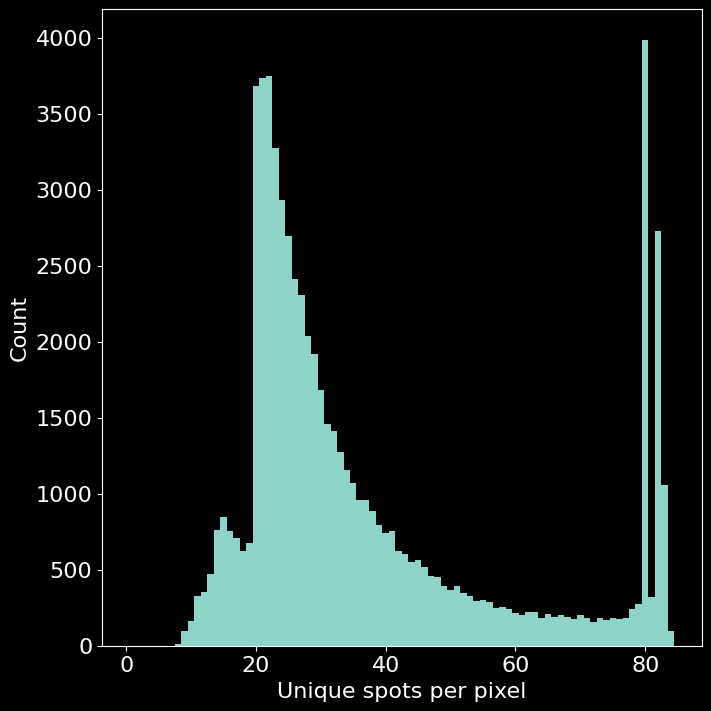

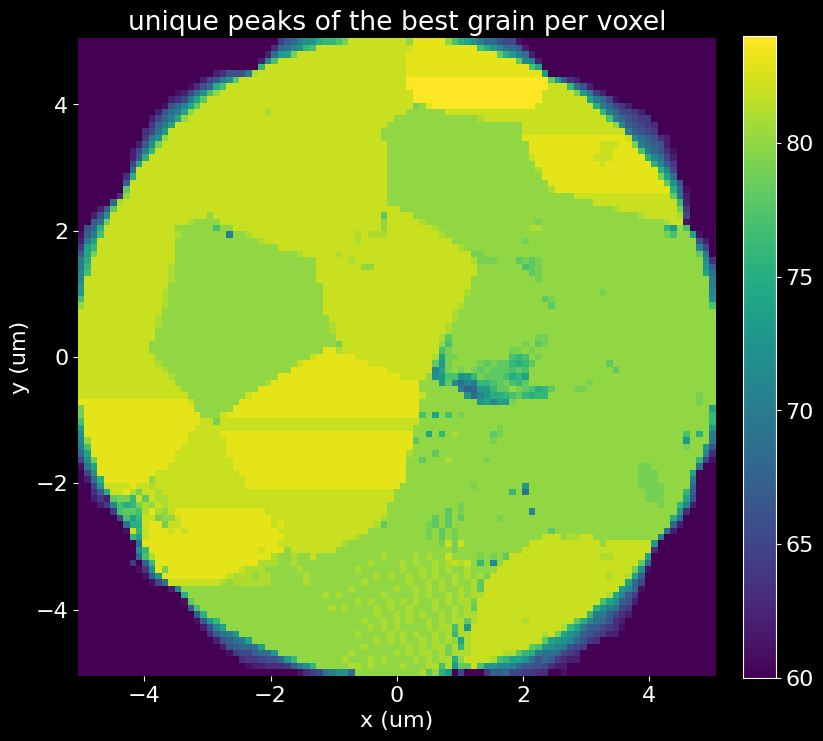

In [7]:
pbpmap = pbp.PBPMap(grains_filename)
pbpmap.plot_nuniq_hist()
pbpmap.choose_best(minpeaks=60)

fig, ax = plt.subplots(1, 1, figsize=(9, 9))
im = ax.pcolormesh(dset.sx_grid, dset.sy_grid, pbpmap.best_nuniq)
ax.set_aspect("equal")
ax.set_xlabel("x (um)")
ax.set_ylabel("y (um)")
ax.set_title("unique peaks of the best grain per voxel")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plot.despine(ax)
plt.show()

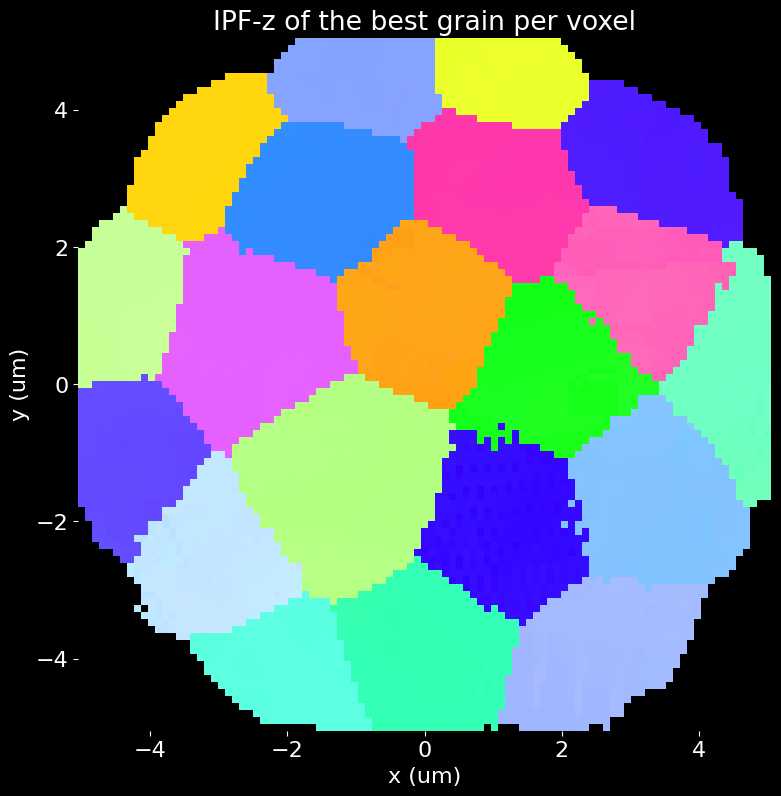

In [8]:
m = ~np.isnan(pbpmap.best_ubi[:, :, 0, 0])
grains = []
for ubi in pbpmap.best_ubi[m]:
    g = ImageD11.grain.grain(ubi)
    g.ref_unitcell = ucell
    grains.append(g)
utils.get_rgbs_for_grains(grains)
rgbmap = np.zeros((ny, ny, 3))
rgbmap[m] = [g.rgb_z for g in grains]

fig, ax = plt.subplots(1, 1, figsize=(9, 9))
ax.pcolormesh(dset.sx_grid, dset.sy_grid, rgbmap)
ax.set_aspect("equal")
ax.set_xlabel("x (um)")
ax.set_ylabel("y (um)")
ax.set_title("IPF-z of the best grain per voxel")
plot.despine(ax)
plt.show()